In [31]:
import numpy as np
import matplotlib.pyplot as plt
import math

from simulation.camera_model      import get_K, get_camera_pose
from simulation.projection        import project_points, filter_visible
from simulation.homography        import homography, decompose_H
from eight_points.eight_point_agl import eight_point
from eight_points.Retrieve_P      import get_R_t_from_epipolar, P_estimation, parallax, find_scaling_factor
from eight_points.RANSAC          import RANSAC, score_H_RANSAC, score_F_RANSAC
from pipeline.score               import score_H, score_F
from eight_points.triangulation   import triangulate

def residual_F(px1, px2, F):
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])
    # Epipolar lines
    Fx1  = F @ h1                                             # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)
    num = np.sum(h2 * Fx1, axis=0) ** 2
    denom1 = Fx1[0]**2 + Fx1[1]**2                            # (N,)
    denom2 = Ftx2[0]**2 + Ftx2[1]**2                          # (N,)
    d2_sym = num * (1.0 / (denom1 + 1e-12) + 1.0 / (denom2 + 1e-12))
    sum_d2_sym = np.sum(d2_sym)
    total_error = np.sqrt(1 / (2*N) * sum_d2_sym)
    return total_error


def make_scene(
    n_points=1000, 
    scene_type='3d', 
    x_range=2.0, 
    y_range=1.5, 
    z_min=5.0, 
    z_max=15.0,
    fx=1000.0, fy=1000.0, cx=960.0, cy=540.0, 
    img_w=1920, img_h=1080,
    cam1_rx=0.0, cam1_ry=0.0, cam1_rz=0.0, cam1_tx=0.0, cam1_ty=0.0, cam1_tz=0.0,
    cam2_rx=0.0, cam2_ry=8.0, cam2_rz=0.0, cam2_tx=1.5, cam2_ty=0, cam2_tz=0.0,
    noise_sigma=1.0, 
    outlier_ratio=0.1,
    seed=42,
    dispersion = None
):
    """
    Generates a synthetic scene seen by two cameras.
    Returns a dict: pts3d, px1, px2, K, R_rel, t_rel, R1, t1.
    """
    rng = np.random.default_rng(seed)

    # 1. Generate 3D Points
    xs = rng.uniform(-x_range, x_range, n_points)
    ys = rng.uniform(-y_range, y_range, n_points)
    if dispersion is not None:
        # 1. Generate random angles between 0 and 2π
        angles = rng.uniform(0, 2 * np.pi, n_points)
        
        # 2. Generate random radii
        # CRITICAL: You must take the square root of the random uniform value!
        # If you don't, your points will cluster heavily in the exact center.
        radii = dispersion * np.sqrt(rng.uniform(0, 1, n_points))
        
        # 3. Convert polar coordinates (radius, angle) back to Cartesian (X, Y)
        xs = radii * np.cos(angles)
        ys = radii * np.sin(angles)

    if scene_type == 'planar':
        zs = np.full(n_points, z_min)
    else:
        lo, hi = min(z_min, z_max), max(z_min, z_max)
        zs = rng.uniform(lo, hi, n_points)

    pts3d = np.vstack([xs, ys, zs])
    
    # 2. Camera Intrinsics
    K = np.array([[fx,  0, cx],
                  [ 0, fy, cy],
                  [ 0,  0,  1]], dtype=np.float64)

    # 3. Camera Poses (Extrinsics)
    R1, t1 = get_camera_pose(cam1_rx, cam1_ry, cam1_rz,
                             cam1_tx, cam1_ty, cam1_tz)
    R2, t2 = get_camera_pose(cam2_rx, cam2_ry, cam2_rz,
                             cam2_tx, cam2_ty, cam2_tz)

    R_rel = R2 @ R1.T
    t_rel = t2 - R_rel @ t1

    # 4. Project and Filter Visible Points
    px1_c, d1 = project_points(pts3d, K, R1, t1)
    px2_c, d2 = project_points(pts3d, K, R2, t2)
    
    vis = (filter_visible(px1_c, d1, img_w, img_h) &
           filter_visible(px2_c, d2, img_w, img_h))

    px1 = px1_c[:, vis].copy()
    px2 = px2_c[:, vis].copy()
    M   = px1.shape[1]

    # 5. Inject Gaussian Noise
    if noise_sigma > 0 and M > 0:
        nrng = np.random.default_rng(seed + 1000)
        px1 += nrng.normal(0, noise_sigma, px1.shape)
        px2 += nrng.normal(0, noise_sigma, px2.shape)

    # 6. Inject Outliers (False Matches)
    if outlier_ratio > 0 and M > 0:
        orng  = np.random.default_rng(seed + 2000)
        n_out = min(max(1, int(round(M * outlier_ratio))), M)
        idx   = orng.choice(M, n_out, replace=False)
        px2[0, idx] = orng.uniform(0, img_w, n_out)
        px2[1, idx] = orng.uniform(0, img_h, n_out)

    return {
        'pts3d': pts3d[:, vis], 
        'px1': px1, 
        'px2': px2,
        'K': K, 
        'R_rel': R_rel, 
        't_rel': t_rel,
        'R1': R1, 
        't1': t1,
    }

def _rot_err(R_est, R_ref):
    tr = np.trace(R_est.T @ R_ref)
    return np.degrees(np.arccos(np.clip((tr - 1) / 2, -1, 1)))


def _trans_err(t_est, t_ref):
    u = t_est / (np.linalg.norm(t_est) + 1e-12)
    v = t_ref / (np.linalg.norm(t_ref) + 1e-12)
    return np.degrees(np.arccos(np.clip(abs(np.dot(u, v)), 0, 1)))

def _trans_mag_err(t_est, t_ref):
    return np.linalg.norm(t_ref - t_est)

def get_dsamp_F(F, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])

    Fx1  = F @ h1                                              # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)

    num      = np.sum(h2 * Fx1, axis=0) ** 2                  # (x2ᵀFx1)²
    denom    = Fx1[0]**2 + Fx1[1]**2 + Ftx2[0]**2 + Ftx2[1]**2
    d_samp   = num / (denom + 1e-12)
    d_samp = np.sqrt(1 / (2 * N) * np.sum(d_samp))
    return d_samp

def get_dsamp_H(H, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])   # (3, N)
    h2 = np.vstack([px2, np.ones((1, N))])   # (3, N)

    # Forward: H · px1 → px2
    p12 = H @ h1
    p12 = p12[:2] / p12[2]
    d12 = np.sum((p12 - px2) ** 2, axis=0)

    # Backward: H⁻¹ · px2 → px1
    p21 = np.linalg.inv(H) @ h2
    p21 = p21[:2] / p21[2]
    d21 = np.sum((p21 - px1) ** 2, axis=0)
    d_samp = d12 + d21
    return d_samp

def get_angles_from_matrix(R):
    # Extract ry (theta)
    # Note: this assumes the matrix is not in a "Gimbal Lock" state (ry != 90 or -90 deg)
    ry = np.arcsin(-R[2, 0])
    
    # Extract rx (phi)
    rx = np.arctan2(R[2, 1], R[2, 2])
    
    # Extract rz (psi)
    rz = np.arctan2(R[1, 0], R[0, 0])
    
    # Convert from radians to degrees
    return np.degrees([rx, ry, rz])

def residual_H(H, px1, px2, type = "One image"):
    N = px1.shape[1]
    
    # Convert to homogeneous coordinates
    h1 = np.vstack([px1, np.ones((1, N))])   # (3, N)
    h2 = np.vstack([px2, np.ones((1, N))])   # (3, N)

    # Forward: H · px1 → px2
    p12 = H @ h1
    p12 = p12[:2] / p12[2] # Dehomogenization
    # Sum over ALL dimensions (both x/y and all N points)
    sum_d12 = np.sum((p12 - px2) ** 2) 

    if type == "One image":
        # Equation 5.1 from the textbook
        res_H = np.sqrt(1 / (2 * N) * sum_d12)
        
    else:
        # Backward: H⁻¹ · px2 → px1
        p21 = np.linalg.inv(H) @ h2
        p21 = p21[:2] / p21[2] # Dehomogenization
        sum_d21 = np.sum((p21 - px1) ** 2)
        
        # Symmetric transfer error
        res_H = np.sqrt(1 / (4 * N) * (sum_d12 + sum_d21))
        
    return res_H

In [ ]:
num_iterations = 1000

angle_true = np.full((3, num_iterations), np.nan)
angle_est  = np.full((3, num_iterations), np.nan)
t_true_arr = np.full((3, num_iterations), np.nan)
t_est      = np.full((3, num_iterations), np.nan)
res_F         = np.full(num_iterations, np.nan)
R_error       = np.full(num_iterations, np.nan)
t_error       = np.full(num_iterations, np.nan)
Repro_error   = np.full(num_iterations, np.nan)
Ransac_mask   = np.full(num_iterations, np.nan)
t_error_mag_F = np.full(num_iterations, np.nan)
nb_points = 0
rx_deg = np.random.uniform(-10, 10)
ry_deg = np.random.uniform(-10, 10)
rz_deg = np.random.uniform(-10, 10)

tx = np.random.uniform(-2, 2)
ty= np.random.uniform(1, 3)
tz = np.random.uniform(-2.5, 2.5)
for count in range(num_iterations):
    nb_points = 0
    scene_data = make_scene(n_points=1000, outlier_ratio=0.1, noise_sigma=1, cam2_rx=rx_deg, cam2_ry=ry_deg,
                                cam2_rz=  rz_deg, cam2_tx=tx, cam2_ty=ty, cam2_tz= tz, seed = count)
    pts3d_vis = scene_data['pts3d']
    px1_vis = scene_data['px1']
    px2_vis = scene_data['px2']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    R_true = scene_data['R_rel']
    t_true = scene_data['t_rel']
    nb_points = px1_vis.shape[1]
    
    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    d_samp = get_dsamp_F(F_Ransac, clean_px1, clean_px2)
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    #7 Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) # First method
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm
    P2 = K @ np.hstack((R2_hat, t2_hat))
    P1 = K@np.hstack((np.eye(3), np.zeros((3, 1))))
    pts3D_triag = triangulate(P1, P2, clean_px1, clean_px2)
    px1_hat, d1 = project_points(pts3D_triag, K, R1, t1)
    px2_hat, d2 = project_points(pts3D_triag, K, R2_hat, t2_hat)
    err1 = np.linalg.norm((clean_px1 - px1_hat), axis = 0)
    err2 = np.linalg.norm((clean_px2 - px2_hat), axis = 0)

    angle_true[:,count] = [rx_deg, ry_deg, rz_deg]
    angle_est[:,count] = get_angles_from_matrix(R2_hat)
    t_true_arr[:,count] = scene_data['t_rel'].flatten()
    t_est[:,count] = t2_hat.flatten()
    res_F[count] = residual_F(clean_px1, clean_px2, F_Ransac)
    R_error[count] = _rot_err(R2_hat, R_true)
    t_error[count] = _trans_err(t2_hat.flatten(), t_true)
    Repro_error[count] = np.mean(err1 + err2)
    Ransac_mask[count] = np.sum(mask)
    t_error_mag_F[count] = _trans_mag_err(t2_hat.flatten(), t_true)

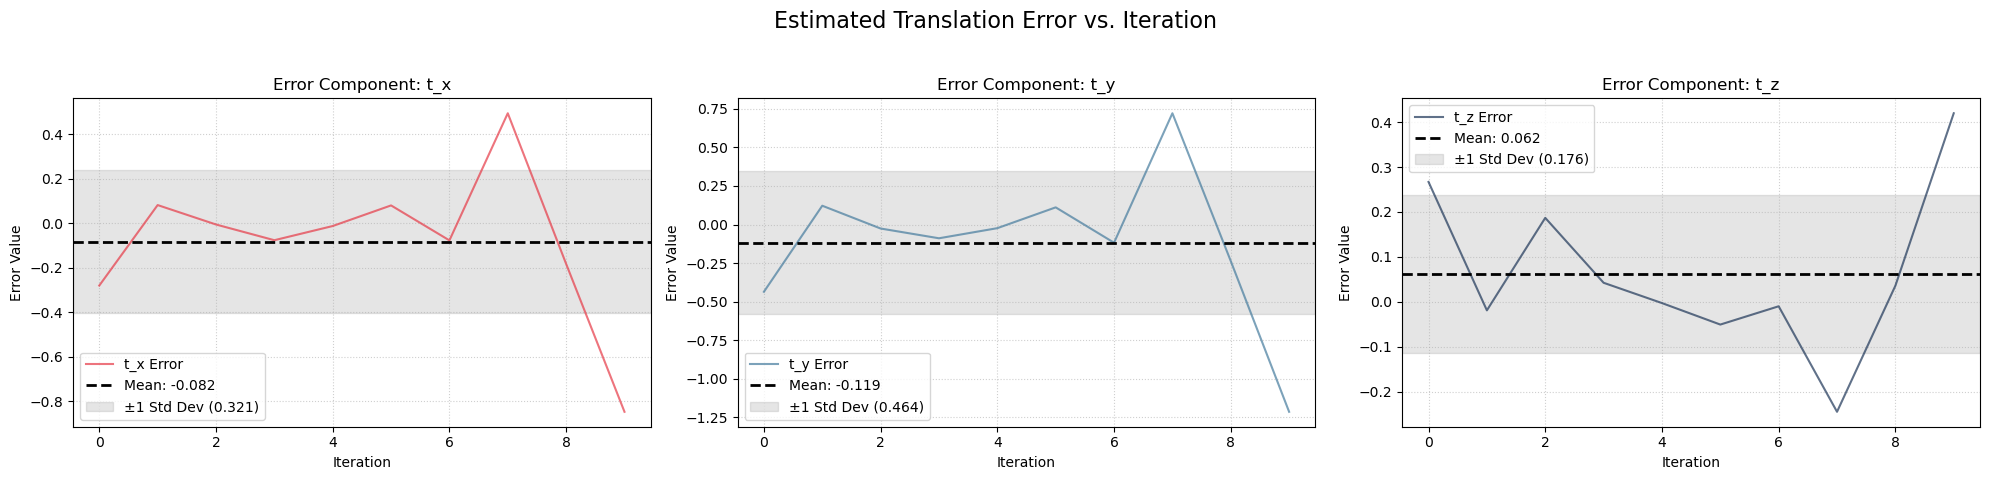

In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Estimated Translation Error vs. Iteration', fontsize=16)

# Labels and colors for the X, Y, Z components
components = ['t_x', 't_y', 't_z']
colors = ['#E63946', '#457B9D', '#1D3557'] # Red, Blue, Dark Blue

axes = [ax1, ax2, ax3]

for i in range(3):
    # Calculate the error for this specific component
    error = t_est[i, :] - t_true_arr[i, :]
    
    # Calculate Mean and Std Deviation (ignoring NaNs)
    mean_err = np.nanmean(error)
    std_err = np.nanstd(error)
    
    # Plot the raw error
    axes[i].plot(error, color=colors[i], linewidth=1.5, alpha=0.7, label=f'{components[i]} Error')
    
    # Plot the Mean as a horizontal dashed line
    axes[i].axhline(y=mean_err, color='black', linestyle='--', linewidth=2, 
                    label=f'Mean: {mean_err:.3f}')
    
    # Plot the Standard Deviation as a shaded region (Mean ± 1 Std Dev)
    axes[i].axhspan(ymin=mean_err - std_err, ymax=mean_err + std_err, 
                    color='gray', alpha=0.2, label=f'±1 Std Dev ({std_err:.3f})')
    
    axes[i].set_title(f'Error Component: {components[i]}')
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('Error Value')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

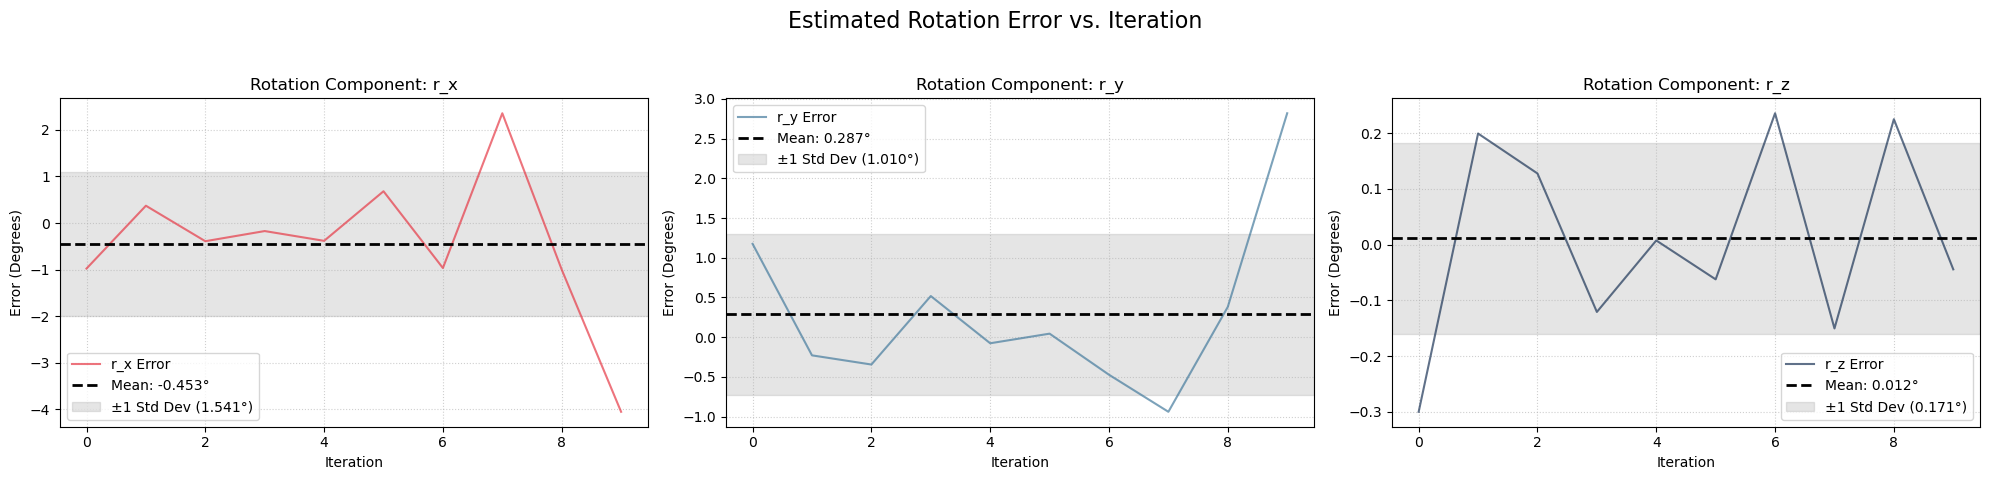

In [34]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Estimated Rotation Error vs. Iteration', fontsize=16)

# Labels and colors for the X, Y, Z components
components = ['r_x', 'r_y', 'r_z']
colors = ['#E63946', '#457B9D', '#1D3557'] # Red, Blue, Dark Blue

axes = [ax1, ax2, ax3]

for i in range(3):
    # Calculate the error for this specific rotation component
    error = angle_est[i, :] - angle_true[i, :]
    
    # Calculate Mean and Std Deviation (ignoring NaNs)
    mean_err = np.nanmean(error)
    std_err = np.nanstd(error)
    
    # Plot the raw error
    axes[i].plot(error, color=colors[i], linewidth=1.5, alpha=0.7, label=f'{components[i]} Error')
    
    # Plot the Mean as a horizontal dashed line
    axes[i].axhline(y=mean_err, color='black', linestyle='--', linewidth=2, 
                    label=f'Mean: {mean_err:.3f}°')
    
    # Plot the Standard Deviation as a shaded region (Mean ± 1 Std Dev)
    axes[i].axhspan(ymin=mean_err - std_err, ymax=mean_err + std_err, 
                    color='gray', alpha=0.2, label=f'±1 Std Dev ({std_err:.3f}°)')
    
    # Corrected titles and labels
    axes[i].set_title(f'Rotation Component: {components[i]}')
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('Error (Degrees)')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

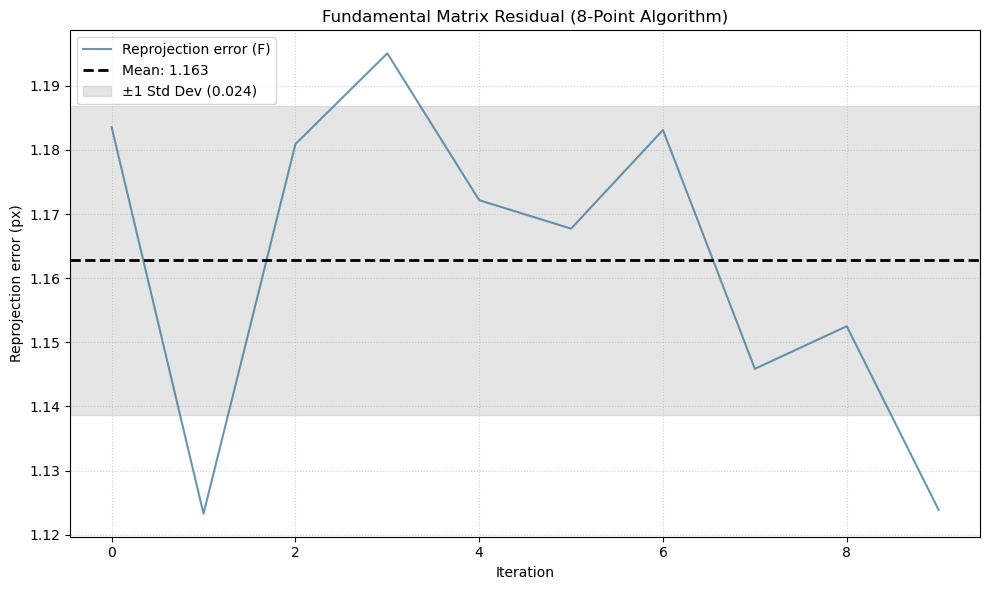

In [35]:
# ==========================================
# Figure 2: Residual Error (F matrix)
# ==========================================
plt.figure(figsize=(10, 6))

# 1. Calculate Statistics
mean_res = np.nanmean(res_F)
std_res = np.nanstd(res_F)

# 2. Plot the raw data as a solid straight line (no markers)
plt.plot(res_F, color='#457B9D', linestyle='-', linewidth=1.5, alpha=0.8, label='Reprojection error (F)')

# 3. Plot Mean and Standard Deviation
plt.axhline(y=mean_res, color='black', linestyle='--', linewidth=2, label=f'Mean: {mean_res:.3f}')
plt.axhspan(ymin=mean_res - std_res, ymax=mean_res + std_res, color='gray', alpha=0.2, label=f'±1 Std Dev ({std_res:.3f})')

# 4. Formatting the plot
plt.title('Fundamental Matrix Residual (8-Point Algorithm)')
plt.xlabel('Iteration')
plt.ylabel('Reprojection error (px)')
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

# Homography

In [36]:
num_iterations = 1000

angle_true = np.full((3, num_iterations), np.nan)
angle_est  = np.full((3, num_iterations), np.nan)
t_true_arr = np.full((3, num_iterations), np.nan)
t_est      = np.full((3, num_iterations), np.nan)
res_H         = np.full(num_iterations, np.nan)
R_error       = np.full(num_iterations, np.nan)
t_error       = np.full(num_iterations, np.nan)
Repro_error   = np.full(num_iterations, np.nan)
Ransac_mask   = np.full(num_iterations, np.nan)
t_error_mag_H = np.full(num_iterations, np.nan)
nb_points = 0

for count in range(num_iterations):
    nb_points = 0
    while nb_points < 100 :
        rx_deg = np.random.uniform(-10, 10)
        ry_deg = np.random.uniform(-10, 10)
        rz_deg = np.random.uniform(-10, 10)

        tx = np.random.uniform(-2, 2)
        ty= np.random.uniform(1, 3)
        tz = np.random.uniform(-2.5, 2.5)


        scene_data = make_scene(n_points=1000, outlier_ratio=0.1, noise_sigma=1, cam2_rx=rx_deg, cam2_ry=ry_deg,
                                cam2_rz=  rz_deg, cam2_tx=tx, cam2_ty=ty, cam2_tz= tz, scene_type="planar", seed=count)
        pts3d_vis = scene_data['pts3d']
        px1_vis = scene_data['px1']
        px2_vis = scene_data['px2']
        K = scene_data['K']
        R1 = np.eye(3)
        t1 = np.zeros((3,1))
        R_true = scene_data['R_rel']
        t_true = scene_data['t_rel']
        plane_dist = 5
        nb_points = px1_vis.shape[1]

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    #d_samp = get_dsamp_H(H_Ransac, clean_px1, clean_px2)
    R_H, t_H = decompose_H(H_Ransac, K, plane_dist=plane_dist,
                                    X_ref=clean_p3d[:, 0])
    P2 = K @ np.hstack((R_H, t_H.reshape(3,1)))
    P1 = K@np.hstack((np.eye(3), np.zeros((3, 1))))
    pts3D_triag = triangulate(P1, P2, clean_px1, clean_px2)
    px1_hat, d1 = project_points(pts3D_triag, K, R1, t1)
    px2_hat, d2 = project_points(pts3D_triag, K, R_H, t_H)
    err1 = np.linalg.norm((clean_px1 - px1_hat),axis = 0)
    err2 = np.linalg.norm((clean_px2 - px2_hat), axis=0)

    angle_true[:,count] = [rx_deg, ry_deg, rz_deg]
    angle_est[:,count] = get_angles_from_matrix(R_H)
    t_true_arr[:,count] = scene_data['t_rel'].flatten()
    t_est[:,count] = t_H.flatten()
    res_H[count] = residual_H(H_Ransac, clean_px1, clean_px2, type = "else")
    R_error[count] = _rot_err(R_H, R_true)
    t_error[count] = _trans_err(t_H.flatten(), t_true)
    Repro_error[count] = np.mean(err1 + err2)
    Ransac_mask[count] = np.sum(mask)
    t_error_mag_H[count] = _trans_mag_err(t_H.flatten(), t_true)

KeyboardInterrupt: 

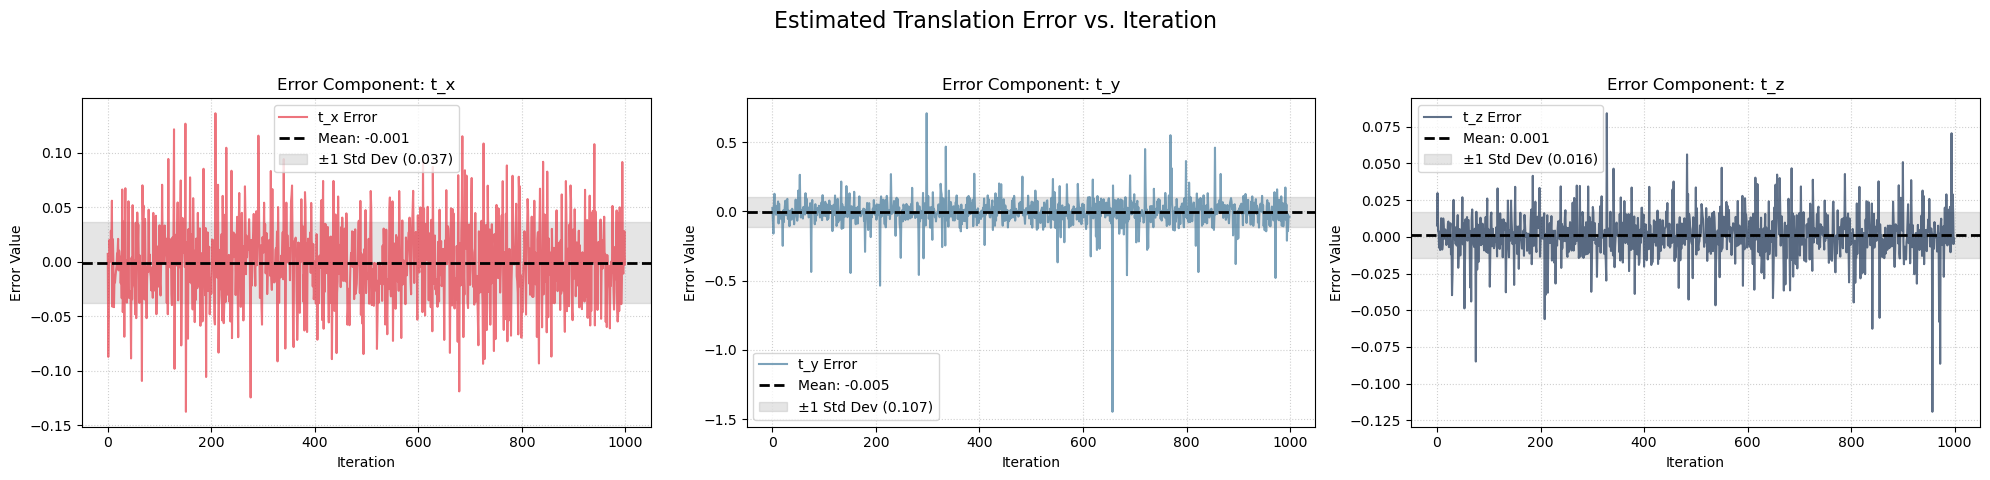

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Estimated Translation Error vs. Iteration', fontsize=16)

# Labels and colors for the X, Y, Z components
components = ['t_x', 't_y', 't_z']
colors = ['#E63946', '#457B9D', '#1D3557'] # Red, Blue, Dark Blue

axes = [ax1, ax2, ax3]

for i in range(3):
    # Calculate the error for this specific component
    error = t_est[i, :] - t_true_arr[i, :]
    
    # Calculate Mean and Std Deviation (ignoring NaNs)
    mean_err = np.nanmean(error)
    std_err = np.nanstd(error)
    
    # Plot the raw error
    axes[i].plot(error, color=colors[i], linewidth=1.5, alpha=0.7, label=f'{components[i]} Error')
    
    # Plot the Mean as a horizontal dashed line
    axes[i].axhline(y=mean_err, color='black', linestyle='--', linewidth=2, 
                    label=f'Mean: {mean_err:.3f}')
    
    # Plot the Standard Deviation as a shaded region (Mean ± 1 Std Dev)
    axes[i].axhspan(ymin=mean_err - std_err, ymax=mean_err + std_err, 
                    color='gray', alpha=0.2, label=f'±1 Std Dev ({std_err:.3f})')
    
    axes[i].set_title(f'Error Component: {components[i]}')
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('Error Value')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

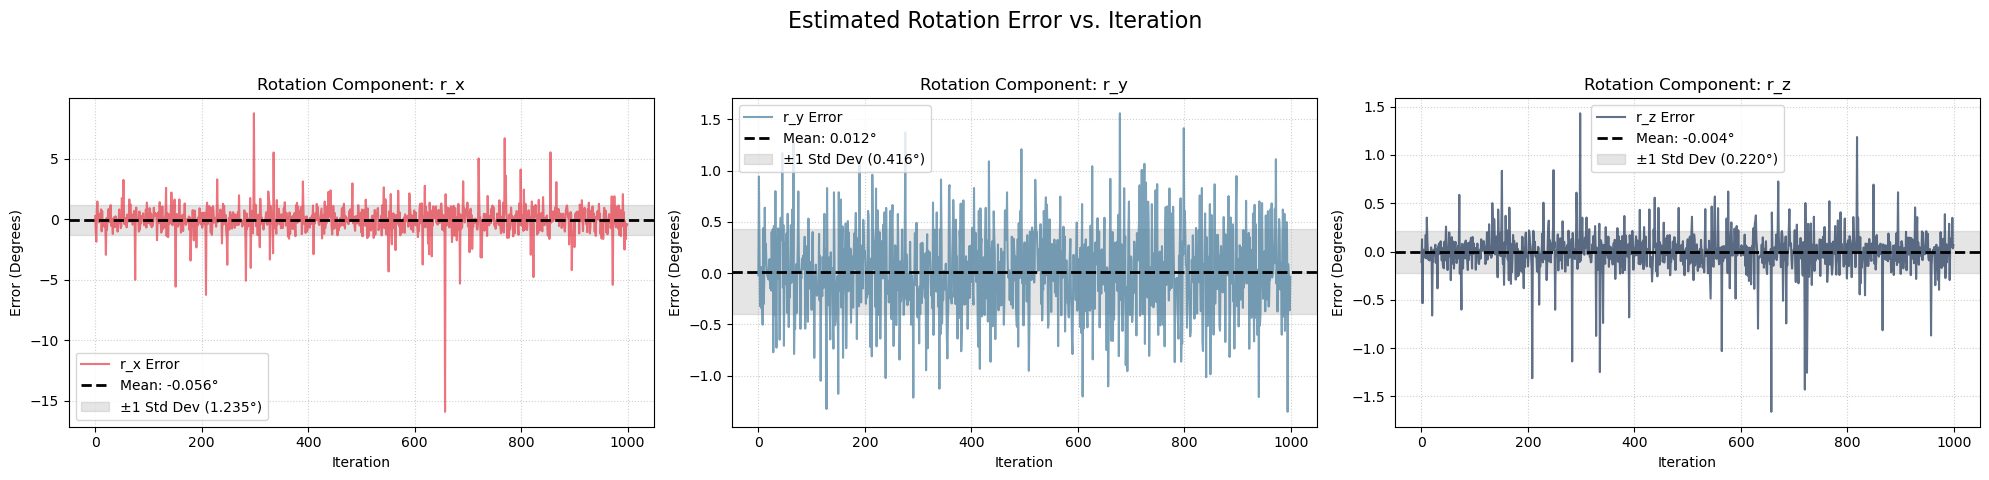

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Estimated Rotation Error vs. Iteration', fontsize=16)

# Labels and colors for the X, Y, Z components
components = ['r_x', 'r_y', 'r_z']
colors = ['#E63946', '#457B9D', '#1D3557'] # Red, Blue, Dark Blue

axes = [ax1, ax2, ax3]

for i in range(3):
    # Calculate the error for this specific rotation component
    error = angle_est[i, :] - angle_true[i, :]
    
    # Calculate Mean and Std Deviation (ignoring NaNs)
    mean_err = np.nanmean(error)
    std_err = np.nanstd(error)
    
    # Plot the raw error
    axes[i].plot(error, color=colors[i], linewidth=1.5, alpha=0.7, label=f'{components[i]} Error')
    
    # Plot the Mean as a horizontal dashed line
    axes[i].axhline(y=mean_err, color='black', linestyle='--', linewidth=2, 
                    label=f'Mean: {mean_err:.3f}°')
    
    # Plot the Standard Deviation as a shaded region (Mean ± 1 Std Dev)
    axes[i].axhspan(ymin=mean_err - std_err, ymax=mean_err + std_err, 
                    color='gray', alpha=0.2, label=f'±1 Std Dev ({std_err:.3f}°)')
    
    # Corrected titles and labels
    axes[i].set_title(f'Rotation Component: {components[i]}')
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('Error (Degrees)')
    axes[i].grid(True, linestyle=':', alpha=0.6)
    axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

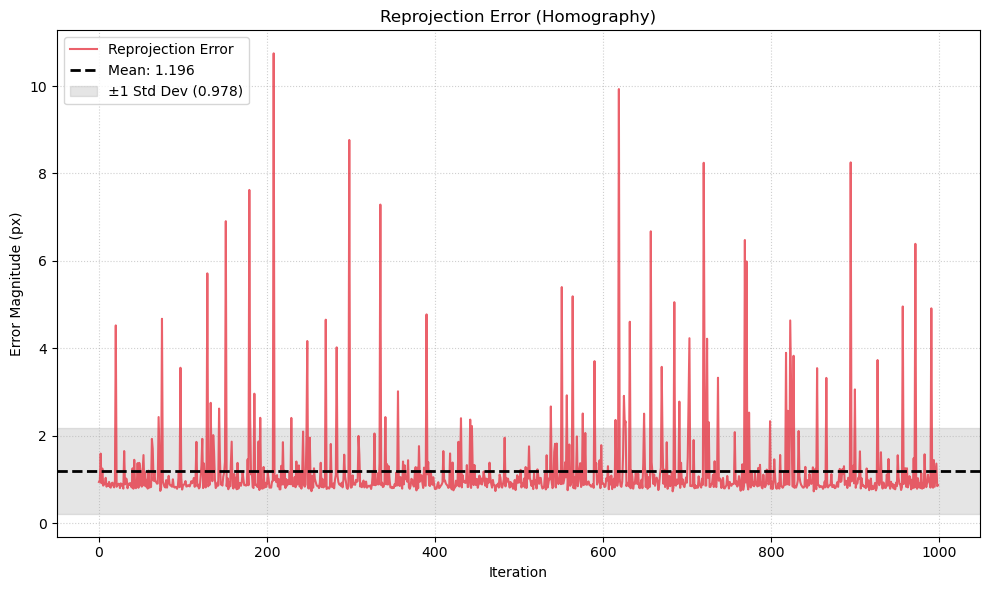

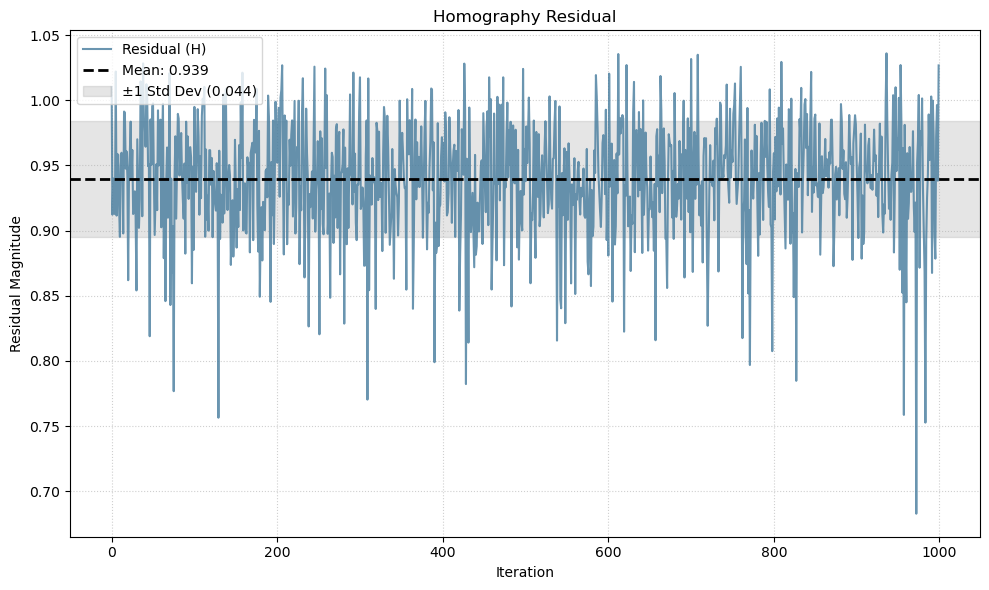

In [ ]:


# ==========================================
# Figure 2: Residual Error (F matrix)
# ==========================================
plt.figure(figsize=(10, 6))

# 1. Calculate Statistics
mean_res = np.nanmean(res_H)
std_res = np.nanstd(res_H)

# 2. Plot the raw data as a solid straight line (no markers)
plt.plot(res_H, color='#457B9D', linestyle='-', linewidth=1.5, alpha=0.8, label='Reprojection error (H)')

# 3. Plot Mean and Standard Deviation
plt.axhline(y=mean_res, color='black', linestyle='--', linewidth=2, label=f'Mean: {mean_res:.3f}')
plt.axhspan(ymin=mean_res - std_res, ymax=mean_res + std_res, color='gray', alpha=0.2, label=f'±1 Std Dev ({std_res:.3f})')

# 4. Formatting the plot
plt.title('Homography Residual')
plt.xlabel('Iteration')
plt.ylabel('Reprojection error')
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

# Planar and None-Planar

In [ ]:
num_iterations = 1000

score_ratio = np.full(num_iterations, np.nan)
angle_true = np.full((3, num_iterations), np.nan)
t_true_arr = np.full((3, num_iterations), np.nan)

res_F = np.full(num_iterations, np.nan)
R_error_F = np.full(num_iterations, np.nan)
t_error_F = np.full(num_iterations, np.nan)
t_error_mag_F = np.full(num_iterations, np.nan)
Repro_error_F = np.full(num_iterations, np.nan)
Ransac_mask_F = np.full(num_iterations, np.nan)
nb_pts_noplan = np.full(num_iterations, np.nan)
angle_est_F  = np.full((3, num_iterations), np.nan)
t_est_F      = np.full((3, num_iterations), np.nan)
d_samp = np.full(num_iterations, np.nan)

res_H = np.full(num_iterations, np.nan)
R_error_H = np.full(num_iterations, np.nan)
t_error_H = np.full(num_iterations, np.nan)
t_error_mag_H = np.full(num_iterations, np.nan)
Repro_error_H = np.full(num_iterations, np.nan)
Ransac_mask_H = np.full(num_iterations, np.nan)
nb_pts_plan = np.full(num_iterations, np.nan)
angle_est_H  = np.full((3, num_iterations), np.nan)
t_est_H      = np.full((3, num_iterations), np.nan)

prop_plan_inlier_H = np.full(num_iterations, np.nan)
prop_noplan_inlier_H = np.full(num_iterations, np.nan)

prop_plan_inlier_F = np.full(num_iterations, np.nan)
prop_noplan_inlier_F = np.full(num_iterations, np.nan)

prop_planar_noplar = np.full(num_iterations, np.nan)
Nb_points = 2000
size_window = np.full(num_iterations, np.nan)

rx_deg = np.random.uniform(-10, 10)
ry_deg = np.random.uniform(-10, 10)
rz_deg = np.random.uniform(-10, 10)

tx = np.random.uniform(-2, 2)
ty= np.random.uniform(1, 3)
tz = np.random.uniform(-2.5, 2.5)

for count in range(num_iterations):
    nb_points = 0

    window = np.random.randint(150, 350)
        
    size_window[count] = window
    u_bound = 1000 + window
    l_bound = 700 - window
    scene_data = make_scene(n_points=Nb_points , outlier_ratio=0, noise_sigma=1, cam2_rx=rx_deg, cam2_ry=ry_deg,
                                cam2_rz=  rz_deg, cam2_tx=tx, cam2_ty=ty, cam2_tz= tz, scene_type="planar", seed=count, x_range= 3, y_range=5)
    pts3d_vis = scene_data['pts3d']
    px1_planar = scene_data['px1']
    px2_planar = scene_data['px2']
    px3d_planar = scene_data['pts3d']
    scene_data = make_scene(n_points=Nb_points , outlier_ratio=0, noise_sigma=1, cam2_rx=rx_deg, cam2_ry=ry_deg,
                                cam2_rz=  rz_deg, cam2_tx=tx, cam2_ty=ty, cam2_tz= tz, seed=count, x_range=10, y_range=10)
    px1_noplanar = scene_data['px1']
    px2_noplanar = scene_data['px2']
    px3d_noplanar = scene_data['pts3d']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    R_true = scene_data['R_rel']
    t_true = scene_data['t_rel']
    inside_mask = (px1_planar[0, :] >= l_bound) & (px1_planar[0, :] <= u_bound)
    outside_mask = (px1_noplanar[0, :] <= l_bound) | (px1_noplanar[0, :] >= u_bound)

    curr_px1_planar = px1_planar[:, inside_mask]
    curr_px2_planar = px2_planar[:, inside_mask]
    curr_px3d_planar = px3d_planar[:, inside_mask]
        
    curr_px1_noplanar = px1_noplanar[:, outside_mask]
    curr_px2_noplanar = px2_noplanar[:, outside_mask]
    curr_px3d_noplanar = px3d_noplanar[:, outside_mask]

    # 3. Track the point counts
    nb_pts_plan[count] = curr_px1_planar.shape[1]
    nb_pts_noplan[count] = curr_px1_noplanar.shape[1]
    prop_planar_noplar = nb_pts_plan/(nb_pts_noplan + 1e-8)

        # 4. Stack the temporary variables safely
    px1_combined = np.hstack((curr_px1_planar, curr_px1_noplanar))
    px2_combined = np.hstack((curr_px2_planar, curr_px2_noplanar))
    px3d_combined = np.hstack((curr_px3d_planar, curr_px3d_noplanar))
    nb_points = px1_combined.shape[1]

    t_true_arr[:,count] = scene_data['t_rel'].flatten()
    angle_true[:,count] = [rx_deg, ry_deg, rz_deg]
    plane_dist = 5

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_combined, 
        px2=px2_combined,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    n_plan = int(nb_pts_plan[count])
    
    # Count how many True values are in the planar vs non-planar halves of the mask
    inliers_plan_H = np.sum(mask[:n_plan])
    inliers_noplan_H = np.sum(mask[n_plan:])
    total_inliers_H = np.sum(mask)
    
    # Calculate the proportion of the inlier set
    prop_plan_inlier_H[count] = inliers_plan_H / total_inliers_H
    prop_noplan_inlier_H[count] = inliers_noplan_H / total_inliers_H

    clean_px1 = px1_combined[:, mask]
    clean_px2 = px2_combined[:, mask]
    clean_p3d = px3d_combined[:, mask]
    #d_samp = get_dsamp_H(H_Ransac, clean_px1, clean_px2)
    R_H, t_H = decompose_H(H_Ransac, K, plane_dist=plane_dist,
                                    X_ref=clean_p3d[:, 0])
    P2 = K @ np.hstack((R_H, t_H.reshape(3,1)))
    P1 = K@np.hstack((np.eye(3), np.zeros((3, 1))))
    pts3D_triag = triangulate(P1, P2, clean_px1, clean_px2)
    px1_hat, d1 = project_points(pts3D_triag, K, R1, t1)
    px2_hat, d2 = project_points(pts3D_triag, K, R_H, t_H)
    err1 = np.linalg.norm((clean_px1 - px1_hat),axis = 0)
    err2 = np.linalg.norm((clean_px2 - px2_hat), axis=0)
    S_H      = score_H(H_Ransac, clean_px1, clean_px2)    
    # Total symmetric reprojection error
    total_squared_errors = err1 + err2
    res_H[count] = residual_H(H_Ransac, clean_px1, clean_px2, type = "else")
    R_error_H[count] = _rot_err(R_H, R_true)
    t_error_H[count] = _trans_err(t_H.flatten(), t_true)
    t_error_mag_H[count] = _trans_mag_err(t_H.flatten(), t_true)
    Repro_error_H[count] = np.mean(err1 + err2)
    Ransac_mask_H[count] = np.sum(mask)
    t_est_H[:,count] = t_H.flatten()
    angle_est_H[:,count] = get_angles_from_matrix(R_H)

    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_combined, 
        px2=px2_combined,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()

    n_plan = int(nb_pts_plan[count])
    
    inliers_plan_F = np.sum(mask[:n_plan])
    inliers_noplan_F = np.sum(mask[n_plan:])
    total_inliers_F = np.sum(mask)
    
    prop_plan_inlier_F[count] = inliers_plan_F / total_inliers_F
    prop_noplan_inlier_F[count] = inliers_noplan_F / total_inliers_F

    clean_px1 = px1_combined[:, mask]
    clean_px2 = px2_combined[:, mask]
    clean_p3d = px3d_combined[:, mask]
    d_samp[count] = get_dsamp_F(F_Ransac, clean_px1, clean_px2)
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    #7 Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) # First method
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm
    P2 = K @ np.hstack((R2_hat, t2_hat))
    P1 = K@np.hstack((np.eye(3), np.zeros((3, 1))))
    pts3D_triag = triangulate(P1, P2, clean_px1, clean_px2)
    px1_hat, d1 = project_points(pts3D_triag, K, R1, t1)
    px2_hat, d2 = project_points(pts3D_triag, K, R2_hat, t2_hat)
    err1 = np.linalg.norm((clean_px1 - px1_hat),axis=0)
    err2 = np.linalg.norm((clean_px2 - px2_hat), axis=0)
        
    # Total symmetric reprojection error
    total_squared_errors = err1 + err2
    S_F = score_F(F_Ransac, clean_px1, clean_px2)
    res_F[count] = residual_F(clean_px1, clean_px2, F_Ransac)
    R_error_F[count] = _rot_err(R2_hat, R_true)
    t_error_F[count] = _trans_err(t2_hat.flatten(), t_true)
    Repro_error_F[count] = np.mean(err1 + err2)
    Ransac_mask_F[count] = np.sum(mask)
    t_error_mag_F[count] = _trans_mag_err(t2_hat.flatten(), t_true)
    t_est_F[:,count] = t2_hat.flatten()
    angle_est_F[:,count] = get_angles_from_matrix(R2_hat)
    score_ratio[count] = S_H / (S_H + S_F)


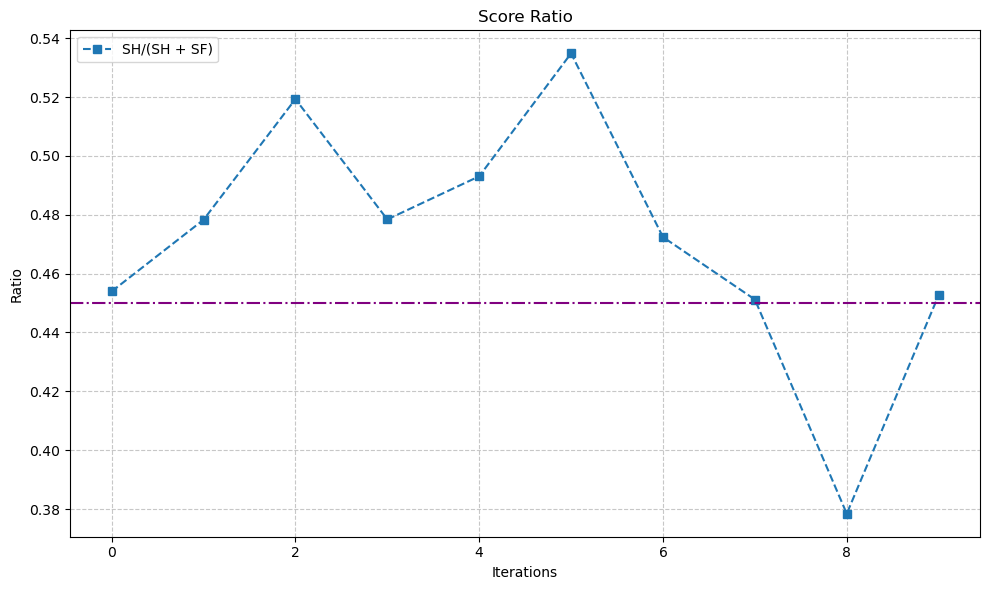

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the four error metrics against the noise_sigmas
plt.plot(score_ratio, label='SH/(SH + SF)', marker='s', linestyle='--')
plt.axhline(y=0.45, color='purple', linestyle='-.')

# Formatting the plot
plt.title('Score Ratio')
plt.xlabel('Iterations')
plt.ylabel('Ratio')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()

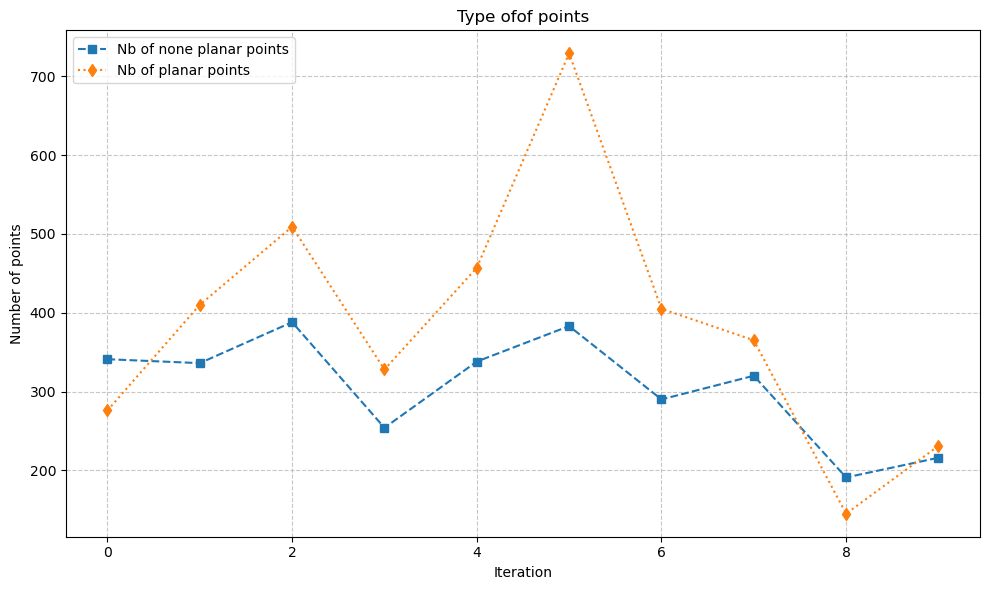

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the four error metrics against the noise_sigmas

plt.plot(prop_planar_noplar , label='Proportion of planar points', marker='s', linestyle='--')

# Formatting the plot
plt.title('Type ofof points')
plt.xlabel('Iteration')
plt.ylabel('Number of points')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()

# Display the plot
plt.show()


<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
C:\Users\thien\AppData\Local\Temp\ipykernel_32296\172832194.py:17: SyntaxWarning: invalid escape sequence '\p'
  color='gray', alpha=0.15, label=f'Std: $\pm${std_F:.4f}')
C:\Users\thien\AppData\Local\Temp\ipykernel_32296\172832194.py:31: SyntaxWarning: invalid escape sequence '\p'
  color='gray', alpha=0.15, label=f'Std: $\pm${std_H:.4f}')


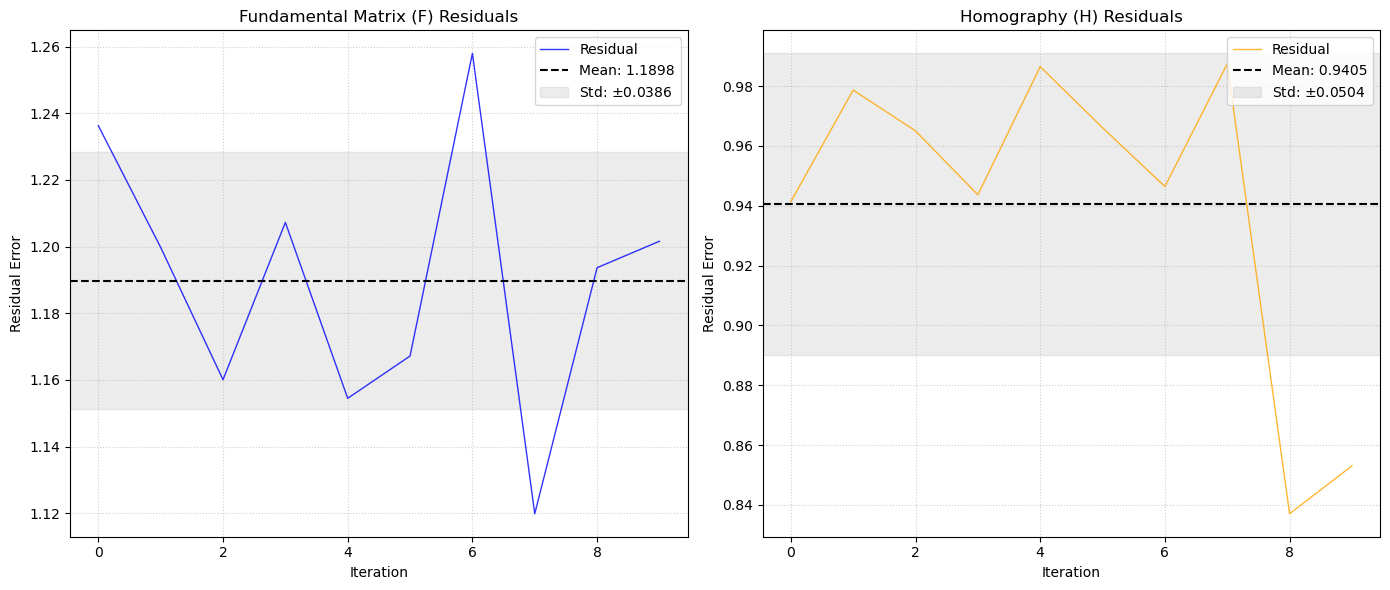

[False False False False False False False False  True False]
[False False False False False False False False False False]


In [ ]:
valid_res_F = res_F[~np.isnan(res_F)]
valid_res_H = res_H[~np.isnan(res_H)]

# 2. Calculate Stats
mean_F, std_F = np.mean(res_F), np.std(res_F)
mean_H, std_H = np.mean(valid_res_H), np.std(valid_res_H)

# 3. Create Side-by-Side Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot Fundamental Matrix (F) Residuals ---
ax1.plot(res_F, color='blue', linewidth=1, alpha=0.8, label='Residual')
ax1.axhline(mean_F, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_F:.4f}')

# Shaded box for Std Dev (Fundamental)
ax1.axhspan(mean_F - std_F, mean_F + std_F, 
            color='gray', alpha=0.15, label=f'Std: $\pm${std_F:.4f}')

ax1.set_title('Fundamental Matrix (F) Residuals')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Residual Error')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper right')

# --- Plot Homography (H) Residuals ---
ax2.plot(res_H, color='orange', linewidth=1, alpha=0.8, label='Residual')
ax2.axhline(mean_H, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_H:.4f}')

# Shaded box for Std Dev (Homography)
ax2.axhspan(mean_H - std_H, mean_H + std_H, 
            color='gray', alpha=0.15, label=f'Std: $\pm${std_H:.4f}')

ax2.set_title('Homography (H) Residuals')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Residual Error')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(score_ratio < 0.45)
print(res_F < res_H)

<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
C:\Users\thien\AppData\Local\Temp\ipykernel_24504\1612446775.py:38: SyntaxWarning: invalid escape sequence '\p'
  ax_F.text(0.05, 0.95, f'Mean: {mean_F:.3f}°\nStd: $\pm${std_F:.3f}°',
C:\Users\thien\AppData\Local\Temp\ipykernel_24504\1612446775.py:63: SyntaxWarning: invalid escape sequence '\p'
  ax_H.text(0.05, 0.95, f'Mean: {mean_H:.3f}°\nStd: $\pm${std_H:.3f}°',


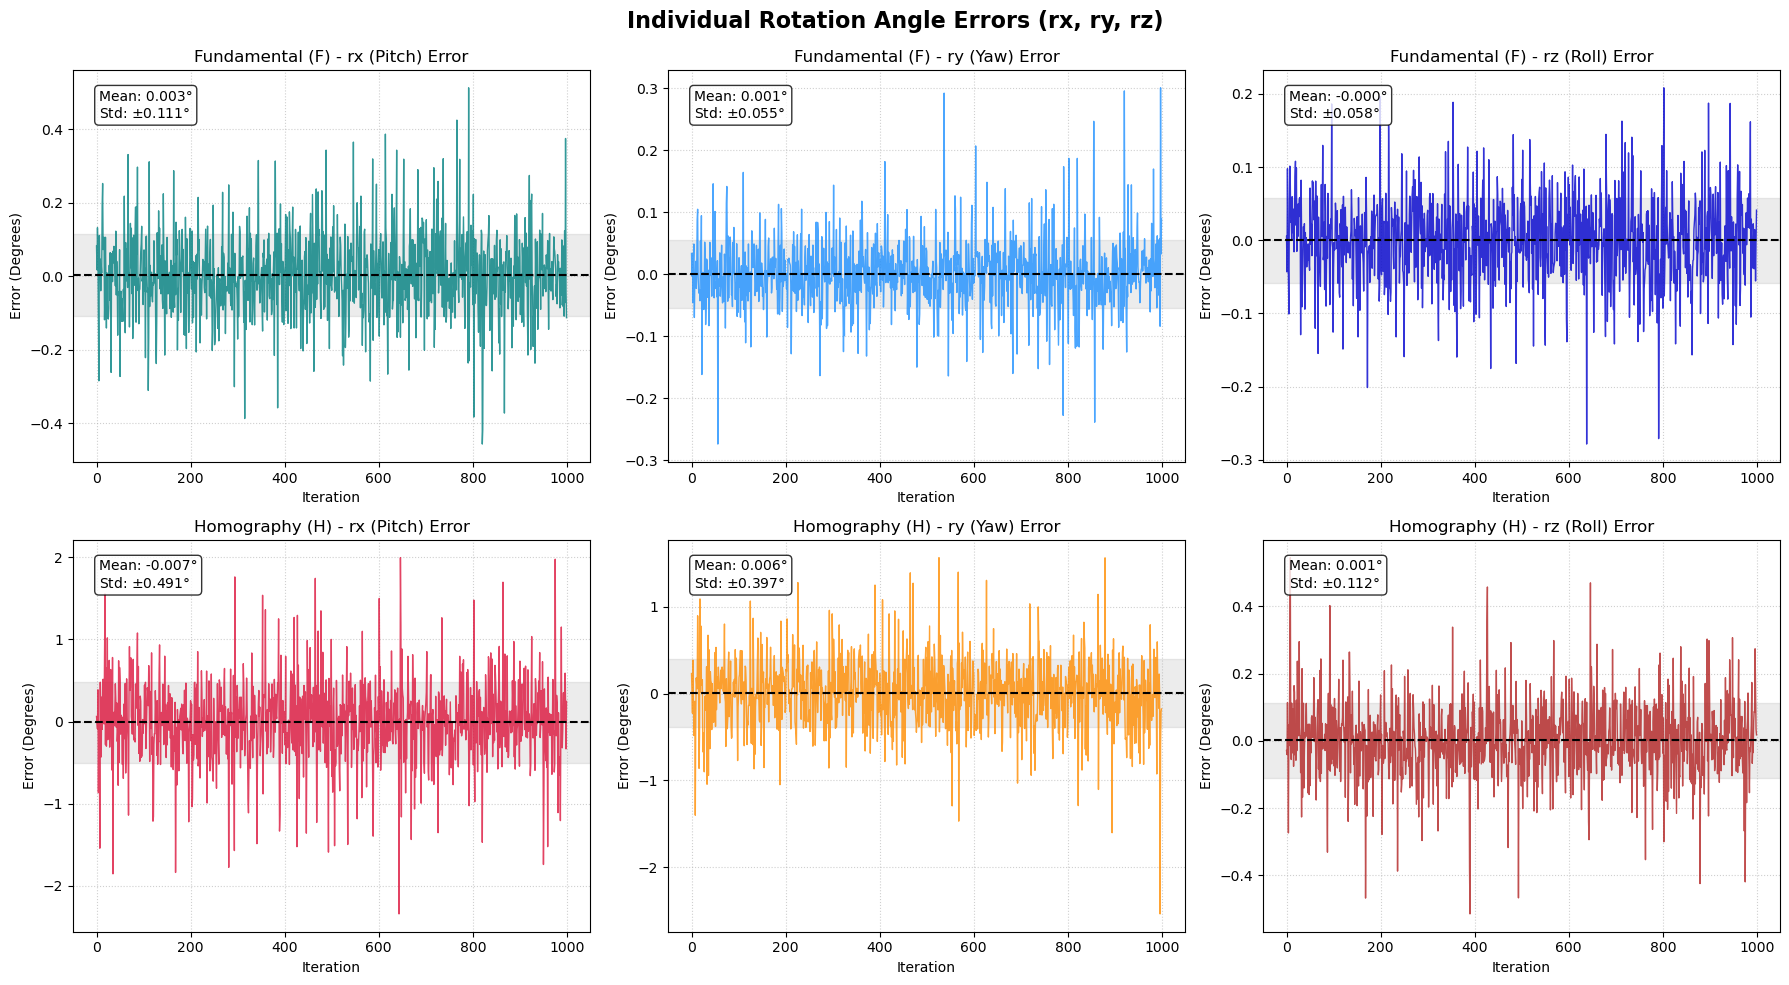

In [ ]:
# 1. Calculate the error for each angle (Estimated - True)
# Both arrays are shape (3, num_iterations)
err_angle_F = angle_est_F - angle_true
err_angle_H = angle_est_H - angle_true

# 2. Set up a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Individual Rotation Angle Errors (rx, ry, rz)', fontsize=16, fontweight='bold')

labels = ['rx (Pitch)', 'ry (Yaw)', 'rz (Roll)']
colors_F = ['teal', 'dodgerblue', 'mediumblue']
colors_H = ['crimson', 'darkorange', 'firebrick']

# Loop through the 3 axes (rx=0, ry=1, rz=2)
for i in range(3):
    
    # ==========================================
    # ROW 1: FUNDAMENTAL MATRIX (F)
    # ==========================================
    ax_F = axes[0, i]
    
    # Filter NaNs for this specific axis
    valid_err_F = err_angle_F[i, ~np.isnan(err_angle_F[i])]
    mean_F, std_F = np.mean(valid_err_F), np.std(valid_err_F)
    
    # Plot
    ax_F.plot(err_angle_F[i], color=colors_F[i], linewidth=1, alpha=0.8)
    ax_F.axhline(mean_F, color='black', linestyle='--', linewidth=1.5)
    ax_F.axhspan(mean_F - std_F, mean_F + std_F, color="gray", alpha=0.15)
    
    # Formatting
    ax_F.set_title(f'Fundamental (F) - {labels[i]} Error')
    ax_F.set_xlabel('Iteration')
    ax_F.set_ylabel('Error (Degrees)')
    ax_F.grid(True, linestyle=':', alpha=0.6)
    
    # Stats Text Box
    ax_F.text(0.05, 0.95, f'Mean: {mean_F:.3f}°\nStd: $\pm${std_F:.3f}°', 
              transform=ax_F.transAxes, verticalalignment='top', 
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # ==========================================
    # ROW 2: HOMOGRAPHY MATRIX (H)
    # ==========================================
    ax_H = axes[1, i]
    
    # Filter NaNs for this specific axis
    valid_err_H = err_angle_H[i, ~np.isnan(err_angle_H[i])]
    mean_H, std_H = np.mean(valid_err_H), np.std(valid_err_H)
    
    # Plot
    ax_H.plot(err_angle_H[i], color=colors_H[i], linewidth=1, alpha=0.8)
    ax_H.axhline(mean_H, color='black', linestyle='--', linewidth=1.5)
    ax_H.axhspan(mean_H - std_H, mean_H + std_H, color="gray", alpha=0.15)
    
    # Formatting
    ax_H.set_title(f'Homography (H) - {labels[i]} Error')
    ax_H.set_xlabel('Iteration')
    ax_H.set_ylabel('Error (Degrees)')
    ax_H.grid(True, linestyle=':', alpha=0.6)
    
    # Stats Text Box
    ax_H.text(0.05, 0.95, f'Mean: {mean_H:.3f}°\nStd: $\pm${std_H:.3f}°', 
              transform=ax_H.transAxes, verticalalignment='top', 
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# Adjust the top margin slightly so the main suptitle doesn't overlap
plt.subplots_adjust(top=0.92)
plt.show()

<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
C:\Users\thien\AppData\Local\Temp\ipykernel_24504\900273583.py:39: SyntaxWarning: invalid escape sequence '\p'
  ax_F.text(0.05, 0.95, f'Mean: {mean_F:.4f}\nStd: $\pm${std_F:.4f}',
C:\Users\thien\AppData\Local\Temp\ipykernel_24504\900273583.py:64: SyntaxWarning: invalid escape sequence '\p'
  ax_H.text(0.05, 0.95, f'Mean: {mean_H:.4f}\nStd: $\pm${std_H:.4f}',


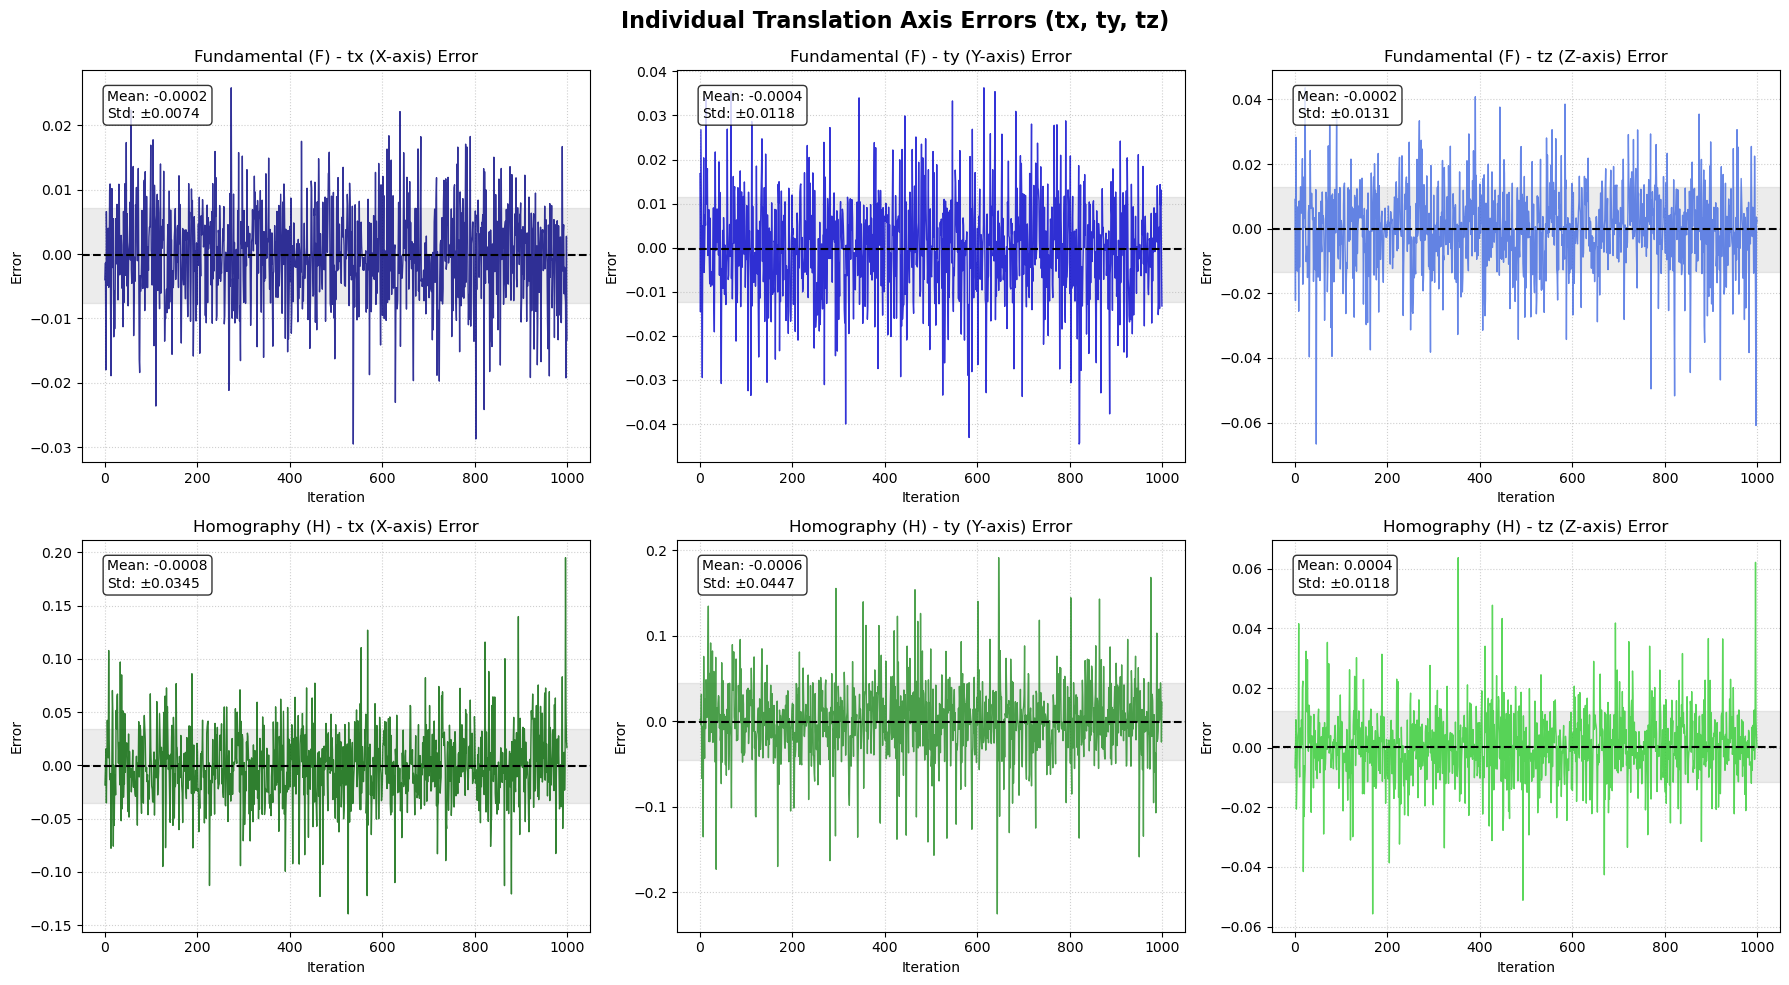

In [ ]:
# 1. Calculate the error for each translation axis (Estimated - True)
# Arrays are shape (3, num_iterations)
err_t_F = t_est_F - t_true_arr
err_t_H = t_est_H - t_true_arr

# 2. Set up a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Individual Translation Axis Errors (tx, ty, tz)', fontsize=16, fontweight='bold')

labels = ['tx (X-axis)', 'ty (Y-axis)', 'tz (Z-axis)']
# Distinct colors for Translation to tell them apart from Rotation
colors_F = ['navy', 'mediumblue', 'royalblue'] 
colors_H = ['darkgreen', 'forestgreen', 'limegreen']

# Loop through the 3 axes (tx=0, ty=1, tz=2)
for i in range(3):
    
    # ==========================================
    # ROW 1: FUNDAMENTAL MATRIX (F)
    # ==========================================
    ax_F = axes[0, i]
    
    # Filter NaNs for this specific axis
    valid_err_F = err_t_F[i, ~np.isnan(err_t_F[i])]
    mean_F, std_F = np.mean(valid_err_F), np.std(valid_err_F)
    
    # Plot
    ax_F.plot(err_t_F[i], color=colors_F[i], linewidth=1, alpha=0.8)
    ax_F.axhline(mean_F, color='black', linestyle='--', linewidth=1.5)
    ax_F.axhspan(mean_F - std_F, mean_F + std_F, color="gray", alpha=0.15)
    
    # Formatting
    ax_F.set_title(f'Fundamental (F) - {labels[i]} Error')
    ax_F.set_xlabel('Iteration')
    ax_F.set_ylabel('Error')
    ax_F.grid(True, linestyle=':', alpha=0.6)
    
    # Stats Text Box
    ax_F.text(0.05, 0.95, f'Mean: {mean_F:.4f}\nStd: $\pm${std_F:.4f}', 
              transform=ax_F.transAxes, verticalalignment='top', 
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # ==========================================
    # ROW 2: HOMOGRAPHY MATRIX (H)
    # ==========================================
    ax_H = axes[1, i]
    
    # Filter NaNs for this specific axis
    valid_err_H = err_t_H[i, ~np.isnan(err_t_H[i])]
    mean_H, std_H = np.mean(valid_err_H), np.std(valid_err_H)
    
    # Plot
    ax_H.plot(err_t_H[i], color=colors_H[i], linewidth=1, alpha=0.8)
    ax_H.axhline(mean_H, color='black', linestyle='--', linewidth=1.5)
    ax_H.axhspan(mean_H - std_H, mean_H + std_H, color="gray", alpha=0.15)
    
    # Formatting
    ax_H.set_title(f'Homography (H) - {labels[i]} Error')
    ax_H.set_xlabel('Iteration')
    ax_H.set_ylabel('Error')
    ax_H.grid(True, linestyle=':', alpha=0.6)
    
    # Stats Text Box
    ax_H.text(0.05, 0.95, f'Mean: {mean_H:.4f}\nStd: $\pm${std_H:.4f}', 
              transform=ax_H.transAxes, verticalalignment='top', 
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
# Adjust the top margin slightly so the main suptitle doesn't overlap
plt.subplots_adjust(top=0.92)
plt.show()

In [ ]:
thresholds = np.arange(0.3, 0.71, 0.02)
accuracy = np.zeros(len(thresholds))

# enumerate automatically gives us an index (0, 1, 2...) and the threshold value
for idx, thresh in enumerate(thresholds):
    
    # 1. Ground Truth: H is geometrically better when its ERROR is LOWER than F's
    better_geo_H = res_H < res_F
    
    # 2. Algorithm Prediction: H is picked if the SCORE RATIO beats the threshold
    predicted_H_better = score_ratio > thresh
    
    # 3. Check where the prediction matches reality
    correct_predictions_mask = (predicted_H_better == better_geo_H)
    
    # 4. Calculate and save the accuracy for this specific threshold
    accuracy[idx] = np.sum(correct_predictions_mask) / len(correct_predictions_mask)

# --- Visualize the Optimization ---
plt.figure(figsize=(10, 6))

# Plot the accuracy curve
plt.plot(thresholds, accuracy, marker='o', linestyle='-', color='#2A9D8F', linewidth=2.5, label='Prediction Accuracy')

# Mark the ORB-SLAM default threshold for comparison
plt.axvline(x=0.45, color='#E63946', linestyle='--', linewidth=2, label='ORB-SLAM Default (0.45)')

# Formatting
plt.title('Threshold Optimization: Accuracy vs. Score Ratio', fontweight='bold', fontsize=14)
plt.xlabel('Score Ratio Threshold (R_H)')
plt.ylabel('Accuracy (Proportion Correct)')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

# Print the actual mathematical winner
best_idx = np.argmax(accuracy)
print(f"The mathematically optimal threshold for this dataset is: {thresholds[best_idx]:.2f}")
print(f"Peak Accuracy: {accuracy[best_idx] * 100:.2f}%")


SCORE RATIO PREDICTION ACCURACY (VECTORIZED)
The >0.45 threshold was correct 3 out of 10 times.
Total Accuracy: 30.0%
